# Plant Disease Detection Using a PyTorch CNN

This notebook builds a plant disease classifier with PyTorch and uses CUDA when available.

## Dataset Structure

Set `DATA_DIR` to a folder structured like:
- `DATA_DIR/class_1/*.jpg`
- `DATA_DIR/class_2/*.jpg`
- ...

## CUDA Setup

This notebook uses PyTorch with CUDA when available. If your system does not detect a GPU, install the CUDA-enabled PyTorch build and rerun the notebook in a GPU-capable environment.

In [8]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("PyTorch version:", torch.__version__)

Using device: cuda
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
PyTorch version: 2.5.1+cu121


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15
Training samples: 14446
Validation samples: 3095
Test samples: 3097


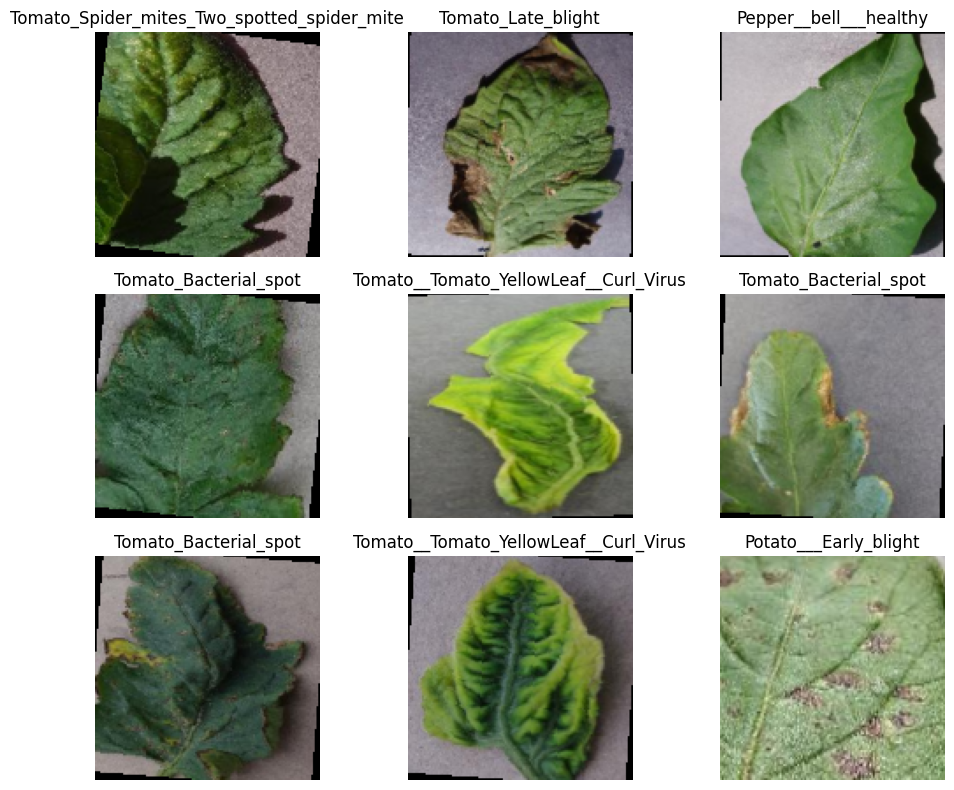

In [9]:
DATA_DIR = "PlantVillage"
IMG_SIZE = 128
BATCH_SIZE = 32
SEED = 42

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"Dataset directory '{DATA_DIR}' not found. Set DATA_DIR to your plant disease dataset path."
    )

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)
val_dataset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)
test_dataset.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

sample_loader = DataLoader(train_dataset, batch_size=9, shuffle=True)
images, labels = next(iter(sample_loader))
plt.figure(figsize=(10, 8))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

Preprocessing pipeline:
- Train: RandomResizedCrop + Flip + Rotation + Normalize
- Val/Test: Resize + Normalize
Batch image tensor shape: torch.Size([32, 3, 128, 128])
Batch labels shape: torch.Size([32])
Pixel value range (after normalization): -2.1179039478302 to 2.5877127647399902


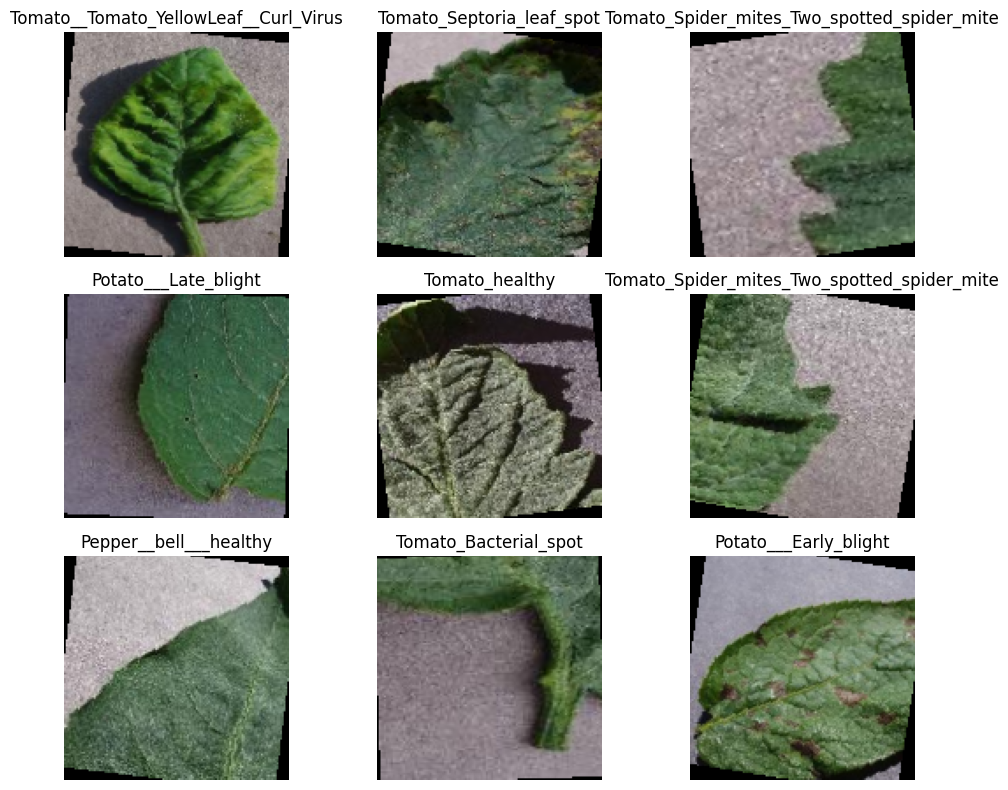

In [10]:
# Data cleaning/preprocessing is already handled by torchvision transforms
# in train_transform and val_transform from the previous cell.

print("Preprocessing pipeline:")
print("- Train: RandomResizedCrop + Flip + Rotation + Normalize")
print("- Val/Test: Resize + Normalize")

# Quick sanity check on one training batch
sanity_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
images, labels = next(iter(sanity_loader))
print("Batch image tensor shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Pixel value range (after normalization):", float(images.min()), "to", float(images.max()))

plt.figure(figsize=(10, 8))
for i in range(min(9, images.size(0))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

class CNNClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNNClassifier(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
early_stop_patience = 4
best_val_acc = 0.0
best_state = None
counter = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print(f"Training on device: {device}")
print(f"pin_memory={pin_memory}")

for epoch in range(1, 16):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= early_stop_patience:
            print("Early stopping triggered")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", round(best_val_acc, 4))

Training on device: cuda
pin_memory=True
Epoch 1: train_loss=1.3493, train_acc=0.5671, val_loss=0.9633, val_acc=0.6856
Epoch 2: train_loss=0.8982, train_acc=0.7096, val_loss=0.9269, val_acc=0.6788
Epoch 3: train_loss=0.7027, train_acc=0.7753, val_loss=0.6098, val_acc=0.8058
Epoch 4: train_loss=0.5875, train_acc=0.8113, val_loss=0.4180, val_acc=0.8640
Epoch 5: train_loss=0.5171, train_acc=0.8373, val_loss=0.2804, val_acc=0.9128
Epoch 6: train_loss=0.4398, train_acc=0.8589, val_loss=0.2869, val_acc=0.9186
Epoch 7: train_loss=0.4115, train_acc=0.8699, val_loss=0.2213, val_acc=0.9338
Epoch 8: train_loss=0.3846, train_acc=0.8765, val_loss=0.2707, val_acc=0.9199
Epoch 9: train_loss=0.3391, train_acc=0.8925, val_loss=0.2342, val_acc=0.9315
Epoch 10: train_loss=0.3438, train_acc=0.8884, val_loss=0.2062, val_acc=0.9370
Epoch 11: train_loss=0.3235, train_acc=0.8950, val_loss=0.2145, val_acc=0.9351
Epoch 12: train_loss=0.3044, train_acc=0.9008, val_loss=0.1565, val_acc=0.9535
Epoch 13: train_loss

Test accuracy: 0.9232

Classification report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.94      0.96       140
                     Pepper__bell___healthy       0.94      0.99      0.97       241
                      Potato___Early_blight       0.99      0.94      0.96       156
                       Potato___Late_blight       0.92      0.92      0.92       168
                           Potato___healthy       0.94      0.77      0.85        22
                      Tomato_Bacterial_spot       0.98      0.96      0.97       335
                        Tomato_Early_blight       0.77      0.85      0.81       150
                         Tomato_Late_blight       0.86      0.97      0.91       274
                           Tomato_Leaf_Mold       0.85      0.99      0.91       139
                  Tomato_Septoria_leaf_spot       0.79      1.00      0.88       264
Tomato_Spider_mite

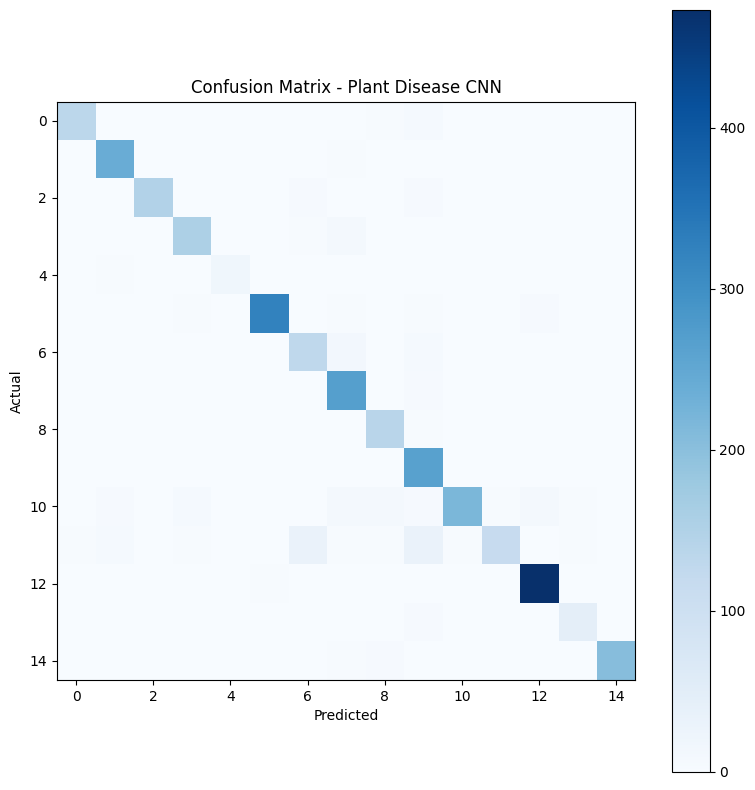

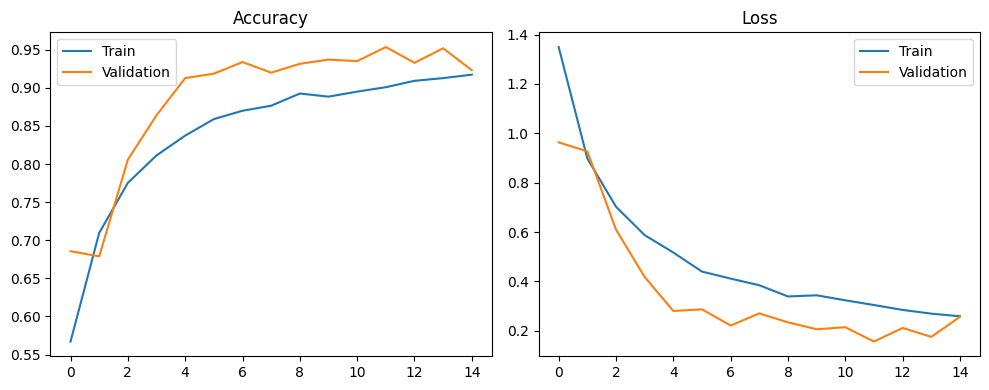

Sample predictions:
Actual: Tomato_Spider_mites_Two_spotted_spider_mite, Predicted: Tomato_Spider_mites_Two_spotted_spider_mite
Actual: Tomato__Tomato_YellowLeaf__Curl_Virus, Predicted: Tomato__Tomato_YellowLeaf__Curl_Virus
Actual: Tomato_Spider_mites_Two_spotted_spider_mite, Predicted: Tomato_Spider_mites_Two_spotted_spider_mite
Actual: Tomato_healthy, Predicted: Tomato_healthy
Actual: Tomato_Bacterial_spot, Predicted: Tomato_Bacterial_spot


In [13]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
cm = confusion_matrix(all_labels, all_preds)
print("Test accuracy:", round(float(accuracy), 4))
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Plant Disease CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.show()

sample_indices = np.random.choice(len(test_dataset), size=5, replace=False)
print("Sample predictions:")
for idx in sample_indices:
    image, label = test_dataset[idx]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
    print(f"Actual: {class_names[label]}, Predicted: {class_names[pred]}")